In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

In [3]:
df= pd.read_csv("house_prices.csv")

In [4]:
df.sample(5)

,House,Size (sq ft),Bedrooms,Age (years),Price ($1000s)
103,104,1534,1,6,188.1
105,106,1518,3,43,169.7
90,91,1068,1,25,90.7
118,119,1466,1,10,168.9
67,68,1730,2,20,204.6


In [5]:
df.isnull().sum()

House             0
Size (sq ft)      0
Bedrooms          0
Age (years)       0
Price ($1000s)    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
X= df.iloc[:, 1:4]
y= df.iloc[:, -1]

# Train Test Split

In [8]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state=42)

# Model Selection

In [9]:
model= DecisionTreeRegressor(max_depth=4, random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

# Price Prediction

In [10]:
y_pred= model.predict(X_test)
result= pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})
print(result)

     Actual Price  Predicted Price
30          177.0       155.365625
172         167.7       155.365625
84          221.0       237.736364
199         195.9       238.735714
60          221.8       190.437037
155         104.3       125.972727
45          138.8       187.610000
182         193.8       155.365625
9           160.0       155.365625
196         382.1       368.820000
136         225.7       238.735714
187         289.7       311.842857
207         256.9       237.736364
126         208.3       237.736364
15          138.5       155.365625
73           80.8       106.166667
165         215.9       190.437037
18          306.8       267.372222
168         201.7       190.437037
93          324.6       317.625000
75          193.1       187.610000
55          234.2       238.735714
147         179.9       125.972727
109          83.1       106.166667
108         222.1       238.735714
142         159.0       155.365625
25          245.5       238.735714
125         268.5   

# Regression Metrics

In [11]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.878618133747958
MAE: 20.84645093938249


# Decision Tree Visualization

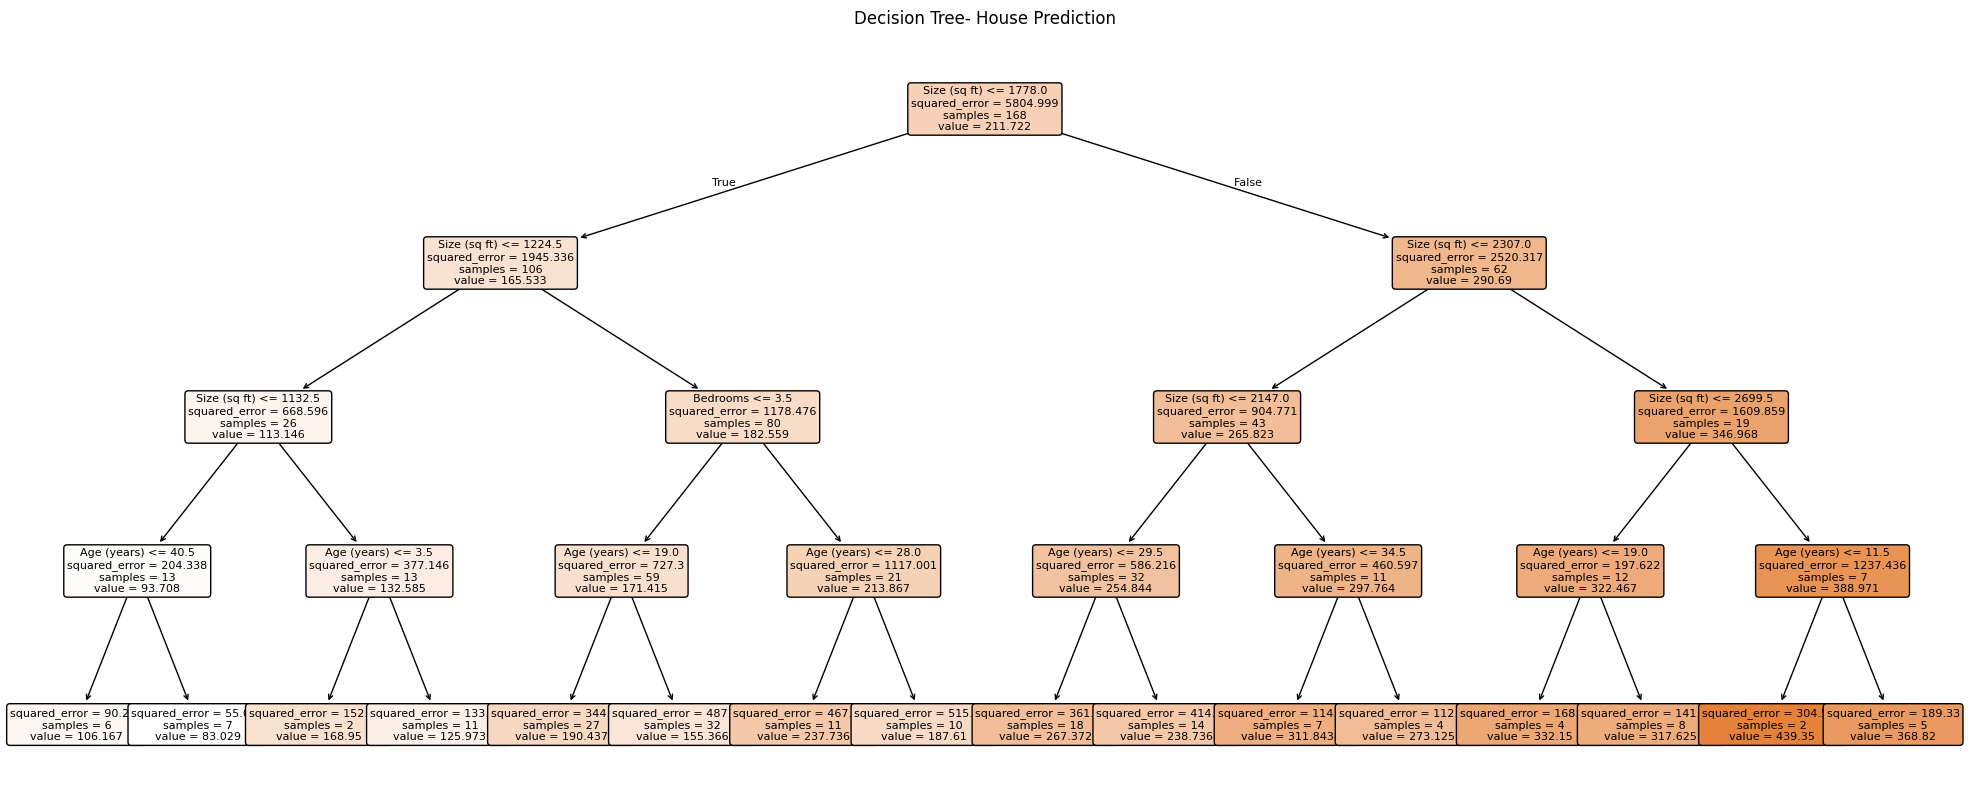

In [13]:
plt.figure(figsize=(25,10))
plot_tree(model, feature_names=X_train.columns, filled= True, rounded= True, fontsize=8)
plt.title("Decision Tree- House Prediction")
plt.show()